# 3. Gradient Boosting

Trees again, but built sequentially instead of independently.

Where a random forest averages many trees fitted in parallel, boosting fits each
new tree to the *residuals* of everything before it — every round explicitly
targets the days the model is still getting wrong. That usually edges out a forest
on tabular data, at the price of being more sensitive to its learning rate and more
willing to overfit if left to run too long.

This uses `HistGradientBoostingRegressor`, the histogram-binned implementation:
same algorithm, dramatically faster, and it ships with scikit-learn so there is no
XGBoost/LightGBM dependency to install.

## Setup

Loads the shared split written by `notebooks/build_modeling_dataset.ipynb`.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model_utils import load_split, evaluate, diagnostic_plots, RANDOM_STATE, PLOT_STYLE

X_train, y_train, X_test, y_test, meta = load_split()

print(f"train: {X_train.shape}  {meta['train_range'][0]} -> {meta['train_range'][1]}")
print(f"test:  {X_test.shape}  {meta['test_range'][0]} -> {meta['test_range'][1]}")
print(f"target: {meta['target']}  |  {meta['n_features']} features")

train: (2554, 37)  2016-01-04 -> 2022-12-31
test:  (1095, 37)  2023-01-01 -> 2025-12-30
target: daily_aqi  |  37 features


## Tuning on the training set only

Hyperparameters are chosen with `TimeSeriesSplit` cross-validation **inside the
training years**, never touching 2023–2025. Ordinary k-fold would shuffle the
calendar and let each fold train on days that come after its validation days;
`TimeSeriesSplit` always validates on a window that follows its training window,
which is the same forward-in-time question the final test asks.

Early stopping is left off during the search so that `max_iter` is tuned honestly
rather than being silently overridden.

In [2]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

MODEL_NAME = 'Gradient Boosting'
tscv = TimeSeriesSplit(n_splits=5)

grid = {
    'learning_rate':    [0.03, 0.06, 0.1],
    'max_iter':         [300, 600],
    'max_leaf_nodes':   [15, 31],
    'min_samples_leaf': [10, 25],
    'l2_regularization': [0.0, 1.0],
}

search = GridSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE, early_stopping=False),
    grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1,
)
search.fit(X_train, y_train)

best = search.best_estimator_
print(f'\nbest params: {search.best_params_}')
print(f'best CV RMSE: {-search.best_score_:.3f}\n')

result = evaluate(MODEL_NAME, best, X_train, y_train, X_test, y_test,
                  params=search.best_params_,
                  notes=f'HistGBR, GridSearchCV over {len(search.cv_results_["params"])} combos, TimeSeriesSplit(5)')

Fitting 5 folds for each of 48 candidates, totalling 240 fits



best params: {'l2_regularization': 1.0, 'learning_rate': 0.03, 'max_iter': 600, 'max_leaf_nodes': 15, 'min_samples_leaf': 10}
best CV RMSE: 21.618

=== Gradient Boosting ===
metric           train      test
RMSE             8.735    19.484
MAE              6.553    13.842
R2               0.944     0.767
MAPE %           7.765    15.818
within10 %      78.504    50.137

overfit gap (test RMSE - train RMSE): +10.749
saved -> models/results/gradient_boosting.json


## Diagnostics

Three views of the same test predictions: how they line up against
truth, whether the errors are patterned or random, and how the model tracks the
actual 2023–2025 series day by day.

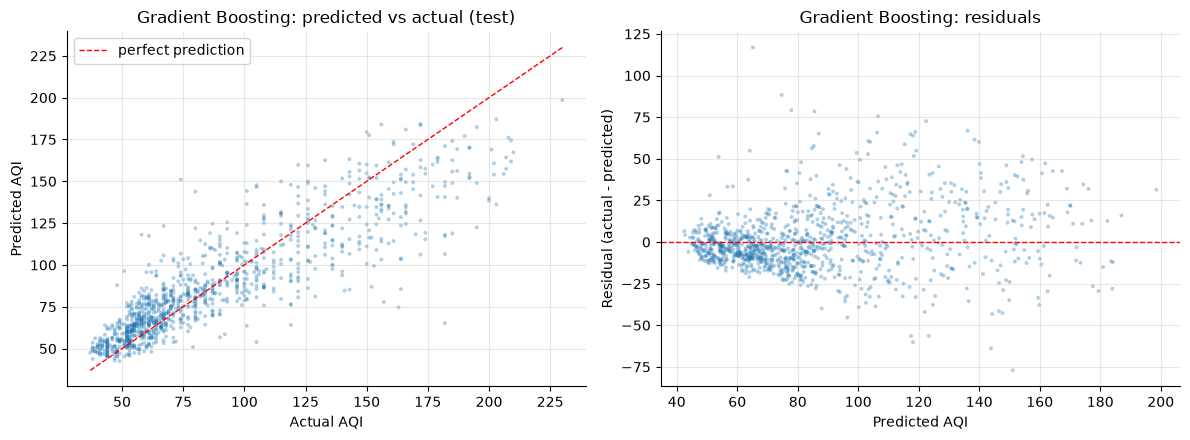

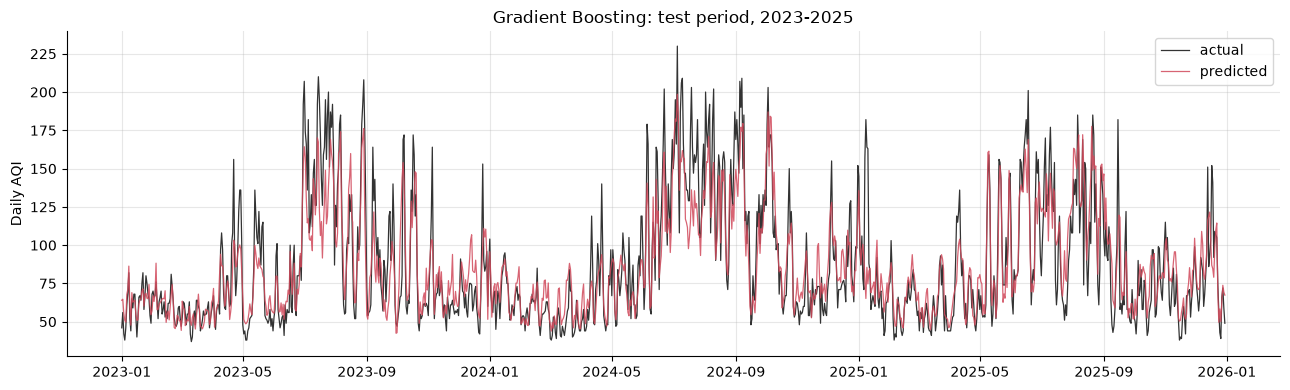

In [3]:
diagnostic_plots(MODEL_NAME, y_test, best.predict(X_test), meta['test_dates'])

## Which features carry the boosted model

`HistGradientBoostingRegressor` exposes no built-in importances, so permutation
importance on the test set is the measurement — which is the more meaningful one
anyway.

Top 15 by permutation importance on test (AQI RMSE points lost when shuffled):
t2m_max                  12.995
doy_cos                   2.048
t2m_max_lag1              1.731
t2m_range                 1.623
doy_sin                   1.357
wind_speed_mean_roll3     1.333
t2m_mean                  0.926
t2m_max_lag2              0.702
wind_speed_mean           0.595
calm_hours                0.592
v10m_mean                 0.553
t2m_max_roll3             0.551
wind_speed_mean_lag1      0.535
wind_speed_max            0.492
u10m_mean                 0.181


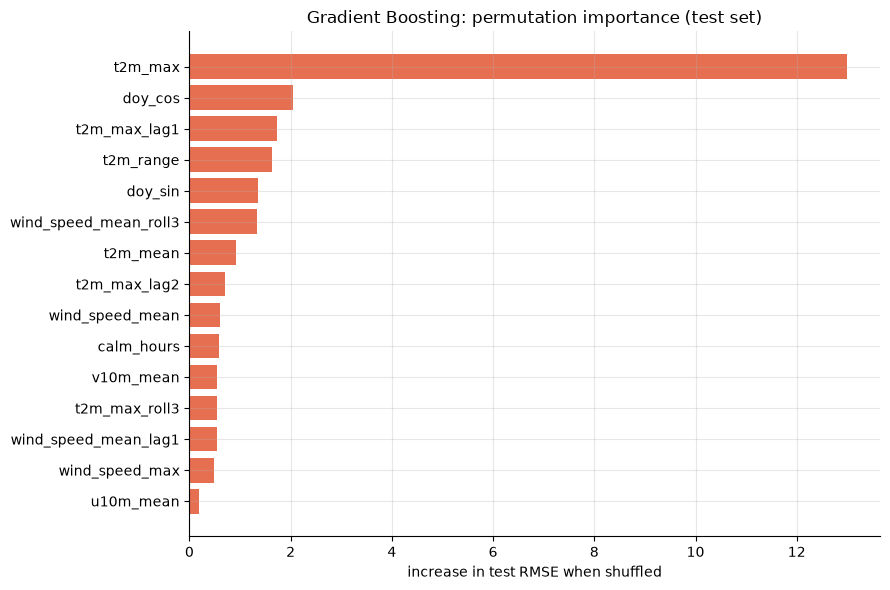

In [4]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best, X_test, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, n_jobs=-1,
                              scoring='neg_root_mean_squared_error')
perm_s = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False)
print('Top 15 by permutation importance on test (AQI RMSE points lost when shuffled):')
print(perm_s.head(15).round(3).to_string())

with plt.rc_context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(9, 6))
    sel = perm_s.head(15)[::-1]
    ax.barh(sel.index, sel.values, color='#e76f51')
    ax.set_xlabel('increase in test RMSE when shuffled')
    ax.set_title('Gradient Boosting: permutation importance (test set)')
    plt.tight_layout(); plt.show()

## What this told us

**Test RMSE 19.5, R² 0.767** — better than the random forest on every test metric,
and the best `within 10 AQI` score of all six models at **50.1%**. Boosting fitting
each tree to the previous residuals pays off exactly as expected.

The overfit gap (+10.7) is nearly as large as the forest's, but note the tuning
chose conservative settings to get there: the slowest learning rate in the grid
(0.03), the smaller trees (15 leaf nodes), and non-zero L2. It compensated with 600
iterations. Given room to be gentle and patient, CV took it.

The importance profile is dramatically more concentrated than the forest's:
`t2m_max` costs **13.0 RMSE points** when shuffled while the runner-up (`doy_cos`)
costs 2.0. Where the forest hedged across the whole correlated temperature block,
boosting funnelled nearly everything through one column and used the rest for
correction. That is the sequential-fitting signature — later trees only need
whatever the earlier ones missed — and it makes the model more compact but more
fragile if that one input were ever unavailable.

`doy_cos` and `doy_sin` again rank second and fifth, reinforcing the finding from
notebook 02: season carries information beyond temperature.